In [62]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [63]:
data_path = os.path.join("..", "Code", "tcf_cleaned.csv")

try:
    tcf_cleaned = pd.read_csv(data_path, encoding='utf-8')
    
    display(tcf_cleaned.head())

except FileNotFoundError:
    print("FileNotFoundError")

,Vendor ID,Vendor Name,Country,Territorial Scope,Environment,Type of Service,International Transfer,Cookie Max Age (days),Data Retention (days)
0,1537,"Branch Metrics, Inc.",United States,"AT, BE, BG, HR, CY, CZ, DK, EE, FI, FR, DE, GR...",Native App (Mobile),"DSP, Ad Serving",SCCs,180,180
1,1382,014 ON,Spain,"AT, BE, BG, HR, CY, CZ, DK, EE, FI, FR, DE, GR...","Web, Native App (Mobile), Native App (CTV)","SSP, DSP, Verification Tool, Ad Serving, Heade...",Adequacy Decision,NaN,730
2,1111,152 Media LLC,Spain,"AT, BE, HR, CY, DK, FI, FR, DE, GR, HU, IE, IT...",Web,Header Bidding Service,No,90,90
3,217,"2KDirect, Inc. (dba iPromote)",United States,"ES, CH, GB","Web, Native App (Mobile)","DSP, Ad Serving, Campaign Analytics, Audience ...",No,1826,31
4,58,33Across,United States,OTHER,Web,"SSP, Ad Serving, DMP / Data Provider, Identity...",No,365,30


In [64]:
# Gatekeeper Score
tcf_cleaned['gatekeeper_score'] = tcf_cleaned['Type of Service'].str.count(',') + 1
tcf_cleaned['gatekeeper_score'] = tcf_cleaned['gatekeeper_score'].fillna(0).astype(int)

display(tcf_cleaned[['Vendor Name', 'Type of Service', 'gatekeeper_score']].sort_values(by='gatekeeper_score', ascending=False).head())

,Vendor Name,Type of Service,gatekeeper_score
852,"TECDO TECHNOLOGY CO., LIMITED","SSP, DSP, Verification Tool, Ad Serving, Heade...",14
555,Mindearth SRL,"SSP, DSP, Verification Tool, Ad Serving, Heade...",14
922,Verasity Limited,"SSP, DSP, Verification Tool, Ad Serving, Heade...",14
923,VeraViews FZ LLC,"SSP, DSP, Verification Tool, Ad Serving, Heade...",14
579,Nadex Limited,"SSP, DSP, Verification Tool, Ad Serving, Heade...",14


In [65]:
# boolean
tcf_cleaned['is_usa'] = (tcf_cleaned['Country'] == 'United States').astype(int)

tcf_cleaned['has_intl_transfer'] = tcf_cleaned['International Transfer'].fillna('No').apply(
    lambda x: 0 if x == 'No' else 1
)

tcf_cleaned['territory_count'] = tcf_cleaned['Territorial Scope'].fillna('').apply(
    lambda x: len([i for i in x.split(',') if i.strip()]) if x else 0
)

In [66]:
# Def for Plotting Correlation between Gatekeeper Score & other columns
def plot_io_correlation(df, x_col, y_col, title=None, use_log=False):

    df_plot = df[[x_col, y_col]].copy()
    df_plot[x_col] = pd.to_numeric(df_plot[x_col], errors='coerce')
    df_plot[y_col] = pd.to_numeric(df_plot[y_col], errors='coerce')
    
    df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna()
    
    if not df_plot.empty:
        upper_limit = df_plot[y_col].quantile(0.99)
        df_plot = df_plot[df_plot[y_col] <= upper_limit]

    if use_log:
        df_plot = df_plot[df_plot[y_col] > 0]
    
    if df_plot.empty:
        print(f"No valid data points for {y_col}")
        return

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    ax = sns.regplot(data=df_plot, x=x_col, y=y_col, 
                     scatter_kws={'alpha': 0.4}, 
                     line_kws={'color': 'red'})
    
    if use_log:
        ax.set_yscale('log')
    
    r_coef, p_val = pearsonr(df_plot[x_col], df_plot[y_col])
    stats_text = f'Pearson R: {r_coef:.3f}\nP-value: {p_val:.3e}'
    
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                   fontsize=12, verticalalignment='top', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.xlabel(x_col)
    plt.ylabel(y_col + (' (Log Scale)' if use_log else ''))
    if title: plt.title(title)
    
    plt.show()

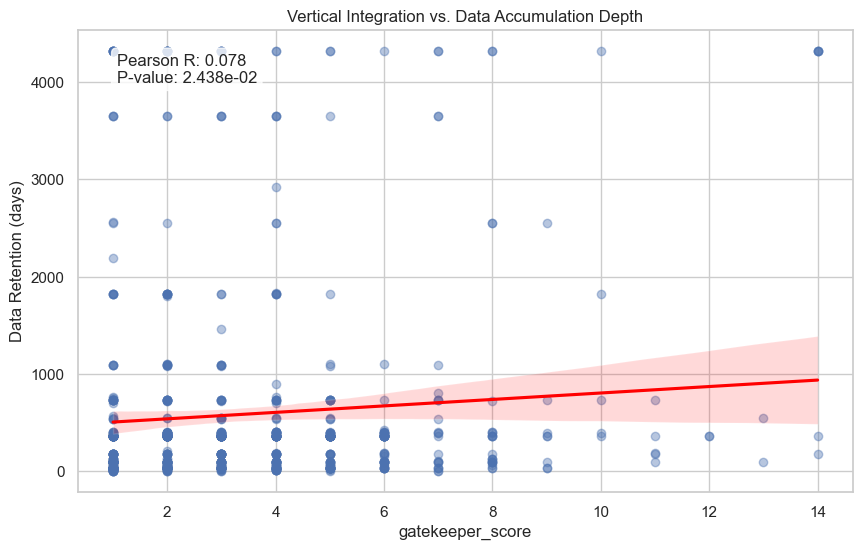

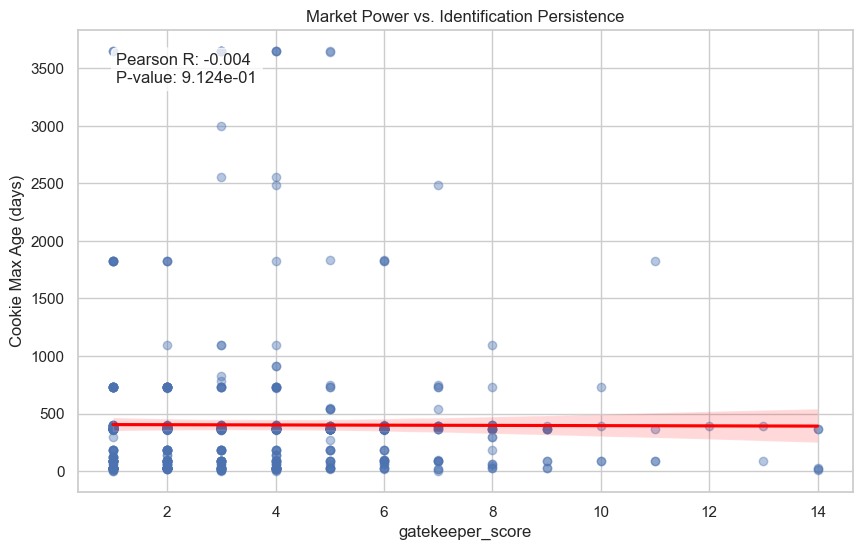

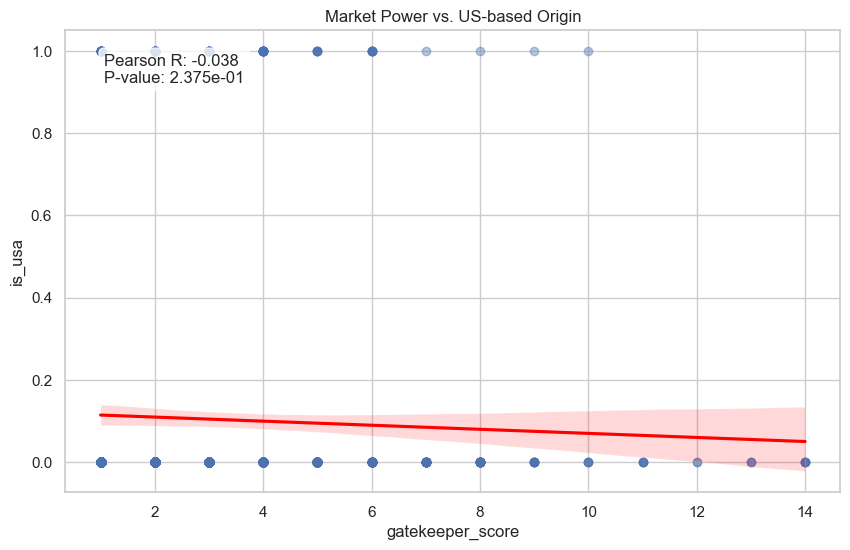

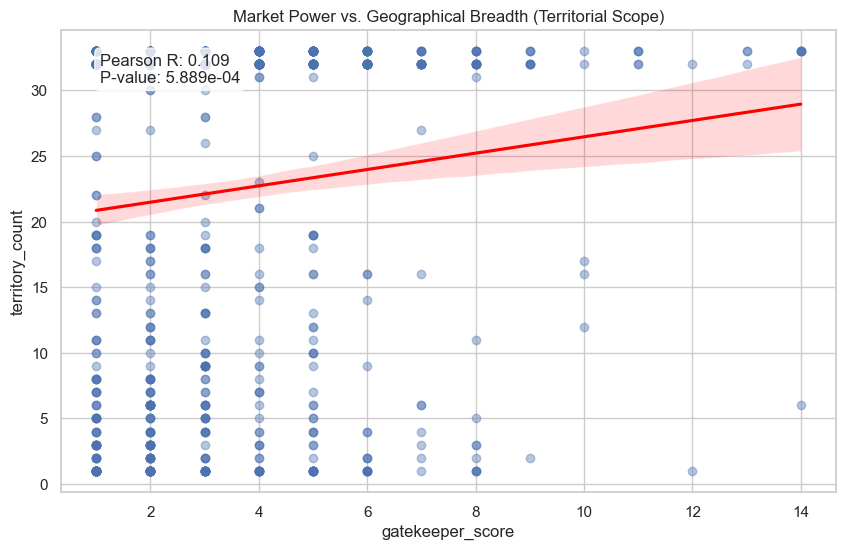

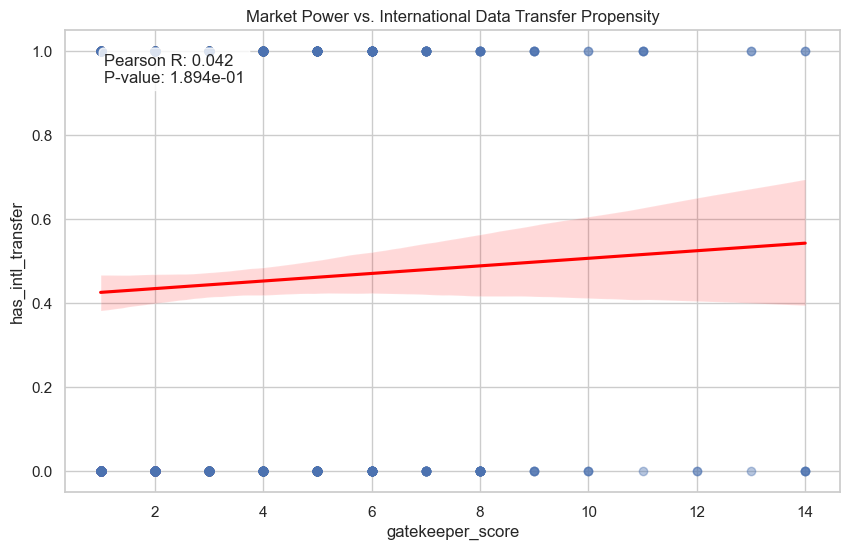

In [67]:
# 1. Hypothesis: Vertical Integration (Gatekeeper Score) leads to longer Data Retention
plot_io_correlation(tcf_cleaned, 'gatekeeper_score', 'Data Retention (days)', 
                    title='Vertical Integration vs. Data Accumulation Depth')

# 2. Hypothesis: Gatekeepers maintain longer tracking persistence (Cookie Age)
plot_io_correlation(tcf_cleaned, 'gatekeeper_score', 'Cookie Max Age (days)', 
                    title='Market Power vs. Identification Persistence')

# 3. Hypothesis: Regulatory Arbitrage - Do Gatekeepers lean towards US jurisdictions?
plot_io_correlation(tcf_cleaned, 'gatekeeper_score', 'is_usa', 
                    title='Market Power vs. US-based Origin')

plot_io_correlation(tcf_cleaned, 'gatekeeper_score', 'territory_count', 
                    title='Market Power vs. Geographical Breadth (Territorial Scope)')

plot_io_correlation(tcf_cleaned, 'gatekeeper_score', 'has_intl_transfer', 
                    title='Market Power vs. International Data Transfer Propensity')